In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import logging

# Imports
from modules.forecasting.data.preprocess_coin import CoinPreprocessor
from modules.forecasting.models.sarimax import SarimaxModel 
from modules.forecasting.data.preprocess_utils import load_scaler_with_meta, _scaler_path_for

# CONFIG & PATHS
PROJECT_ROOT = Path(r"D:\python_projects\crypto-analytics-platform")
SCALER_DIR = PROJECT_ROOT / "src/modules/forecasting/models/scalers"
SARIMAX_DIR = PROJECT_ROOT / "src/modules/forecasting/models/saved/sarimax"

SYMBOL = "BTC"
EXCHANGE = "kraken"
INTERVAL = "1h"
FORECAST_STEPS = 24

print(f"Loading Data for {SYMBOL}")
coin_pre = CoinPreprocessor(scaler_dir=SCALER_DIR) 
try:
    df_recent = coin_pre.load_features_series(SYMBOL, exchange=EXCHANGE, interval=INTERVAL)
    # Take last 1000 rows to avoid early periods where SMA/EMA might be NaN
    df_recent = df_recent.tail(1000).copy()
    print(f"Loaded {len(df_recent)} rows.")
except Exception as e:
    print(f"Data Load Error: {e}")
    sys.exit(1)

Loading Data for BTC
Loaded 1000 rows.


In [7]:
# INVERSE SCALING 
print("Inverse Scaling")
scaler_path = _scaler_path_for(SCALER_DIR, SYMBOL, None)
scaler, cols = load_scaler_with_meta(scaler_path)

if scaler and 'close' in cols:
    matrix = np.zeros((len(df_recent), len(cols)))
    for i, c in enumerate(cols):
        if c in df_recent.columns:
            matrix[:, i] = df_recent[c].values
    close_idx = cols.index('close')
    real_close_prices = scaler.inverse_transform(matrix)[:, close_idx]
    df_recent['real_close'] = real_close_prices
    print(f"Last Real Price: ${df_recent['real_close'].iloc[-1]:,.2f}")
else:
    print("Scaler invalid.")
    sys.exit(1)

Inverse Scaling
Last Real Price: $91,212.10


In [8]:
# SANITIZE DATA 
print("Sanitizing Data")

# A. Calculate Log Returns
df_recent['log_return'] = np.log(df_recent['real_close'] / df_recent['real_close'].shift(1))

# B. Drop NaNs ONLY in log_return (The Fix)
# We interpret infinites as NaN, then drop ONLY rows where log_return is bad
df_recent = df_recent.replace([np.inf, -np.inf], np.nan)
df_recent = df_recent.dropna(subset=['log_return'])

print(f"Final clean rows: {len(df_recent)}")

if df_recent.empty:
    print("CRITICAL: DataFrame is EMPTY. Check for zero prices in data.")
    sys.exit(1)

Sanitizing Data
Final clean rows: 999


In [9]:
# TRAIN 
print("Training SARIMAX")
model = SarimaxModel(
    symbol=SYMBOL,
    order=(1, 0, 1), 
    seasonal_order=(0, 0, 0, 0),
    MODEL_DIR=SARIMAX_DIR
)
logging.getLogger('statsmodels').setLevel(logging.ERROR)

try:
    model.train(df_recent, target_col='log_return')
except Exception as e:
    print(f"Training Failed: {e}")
    sys.exit(1)

Training SARIMAX


c:\Users\sarfras\anaconda3\envs\novum\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\sarfras\anaconda3\envs\novum\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\sarfras\anaconda3\envs\novum\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sarfras\anaconda3\envs\novum\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [10]:
# FORECAST 
print(f"Forecasting {FORECAST_STEPS} steps")
forecast_returns = model.forecast(steps=FORECAST_STEPS)

Forecasting 24 steps


In [12]:
# RECONSTRUCT 
last_real_price = df_recent['real_close'].iloc[-1]
predicted_prices = []
current_price = last_real_price

for log_ret in forecast_returns:
    next_price = current_price * np.exp(log_ret)
    predicted_prices.append(next_price)
    current_price = next_price

# Create Index
last_date = df_recent.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=FORECAST_STEPS, freq='h')
forecast_series = pd.Series(predicted_prices, index=forecast_dates)

print("\nForecast Head:")
print(forecast_series.head())


Forecast Head:
2025-11-19 15:00:00+00:00    91178.816789
2025-11-19 16:00:00+00:00    91211.209136
2025-11-19 17:00:00+00:00    91179.684607
2025-11-19 18:00:00+00:00    91210.364279
2025-11-19 19:00:00+00:00    91180.506548
Freq: h, dtype: float64


--- 6. Plotting ---


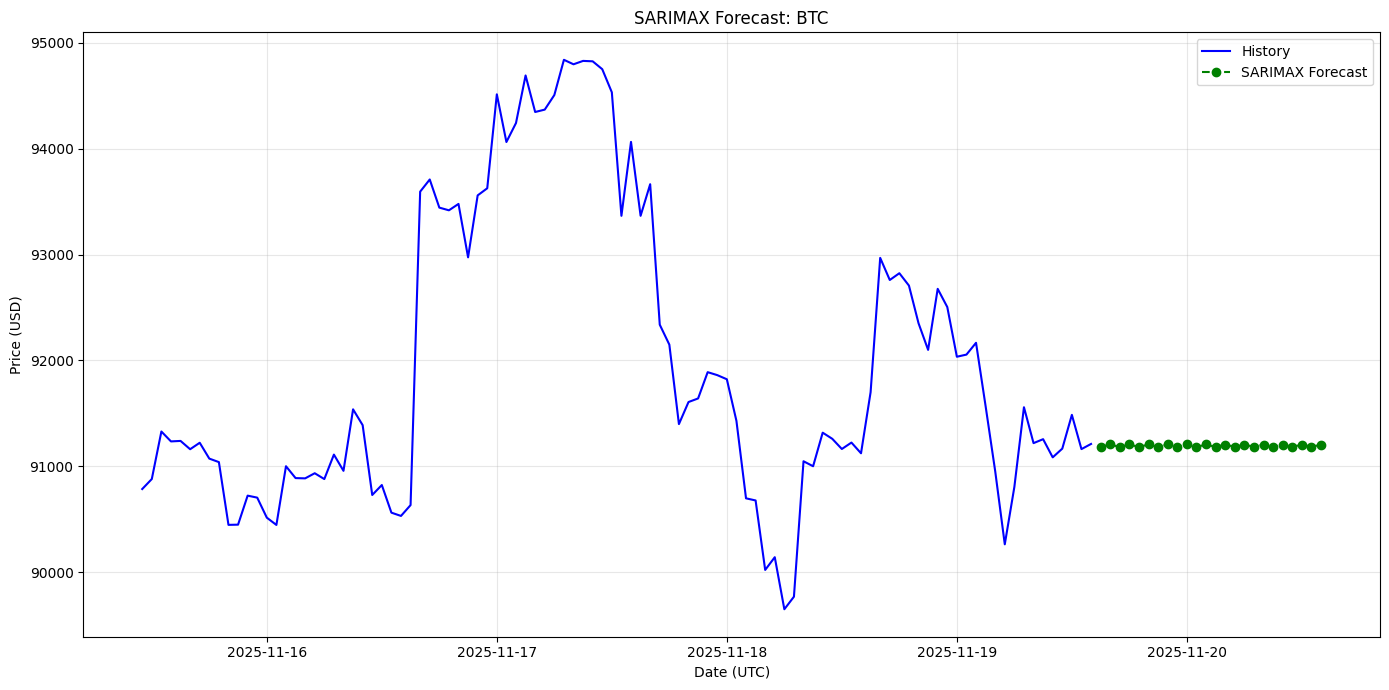

In [13]:
# PLOT 
print("--- 6. Plotting ---")
plt.figure(figsize=(14, 7))
# Plot last 100 hours of history
plt.plot(df_recent.index[-100:], df_recent['real_close'].tail(100), label='History', color='blue')
# Plot forecast
plt.plot(forecast_series.index, forecast_series.values, label='SARIMAX Forecast', color='green', marker='o', linestyle='--')

plt.title(f'SARIMAX Forecast: {SYMBOL}')
plt.xlabel('Date (UTC)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()